<center>


<div style="display: flex; justify-content: center;">
    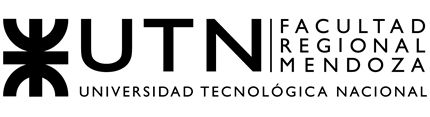
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio n° 5: Análisis de sistemas — Laplace y transformada Z

**Asignatura:** Análisis de Señales y Sistemas
**Requisitos previos:** Módulos 1 a 9, Laboratorios 0 a 4

---

## Introducción

Hasta acá los sistemas se describieron de dos maneras. En el Laboratorio 2, por su **respuesta al impulso**: una lista de números o una función del tiempo que, convolucionada con la entrada, da la salida. En el Laboratorio 4, por su **respuesta en frecuencia**: una curva que dice, frecuencia por frecuencia, por cuánto queda multiplicada la señal que atraviesa el sistema. Las dos descripciones son completas y equivalentes, y el teorema de convolución es el puente entre ellas.

Este laboratorio agrega una tercera, que no aporta información nueva pero sí una forma de leerla que las otras dos no tienen. La idea es que un sistema descrito por una ecuación diferencial —un circuito, un motor, un auto con control crucero— tiene una función de transferencia que es un **cociente de polinomios**, y que un cociente de polinomios queda completamente determinado por dónde están las raíces de esos polinomios. Esas raíces son unos pocos puntos en un plano, y de su posición se lee de un vistazo si el sistema es estable, si oscila, con qué rapidez responde y qué frecuencias privilegia. A las raíces del denominador se las llama **polos** y a las del numerador, **ceros**.

El laboratorio tiene **dos partes**, y la razón de que sean una sola entrega es que son el mismo trabajo escrito dos veces:

- La **Parte A** trabaja con sistemas de tiempo continuo, descritos por ecuaciones diferenciales, y su plano es el **plano $s$** de la transformada de Laplace. La región que decide la estabilidad es el semiplano izquierdo.
- La **Parte B** trabaja con sistemas de tiempo discreto, descritos por ecuaciones en diferencias —las que se implementan en una computadora—, y su plano es el **plano $z$** de la transformada Z. La región que decide la estabilidad es el interior del círculo unitario.

El último ejercicio muestra que esas dos regiones no se parecen por casualidad: hay una fórmula que lleva una a la otra, y es la misma que relaciona un sistema continuo con su versión muestreada.

Al completar este laboratorio vas a poder:

- Construir la función de transferencia $H(s)$ de un sistema con `scipy.signal`, obtener sus polos y ceros y dibujarlos en el plano $s$.
- Predecir la forma de la respuesta al escalón —rápida o lenta, con o sin oscilación, con cuánto sobrepico— mirando únicamente dónde están los polos.
- Explicar que la respuesta en frecuencia del Laboratorio 4 es $H(s)$ evaluada sobre el eje imaginario, y justificar geométricamente por qué aparece un pico de resonancia.
- Cerrar un lazo de realimentación, calcular la transferencia resultante y explicar por qué una acción proporcional deja error de régimen y una acción integral no.
- Reconocer una ganancia excesiva como un par de polos que cruza al semiplano derecho, y relacionar ese cruce con una respuesta que se va a infinito.
- Construir $H(z)$ a partir de una ecuación en diferencias, obtener polos y ceros y dibujarlos respecto del círculo unitario.
- Explicar por qué el eje de frecuencias de un sistema discreto **es** el círculo unitario, y leer $|H|$ como un producto de distancias.
- Enunciar el criterio de estabilidad en los dos planos y justificar, con la relación $z = e^{sT}$, por qué el semiplano izquierdo y el interior del círculo son la misma región.

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Ejecutá las celdas en orden: varios ejercicios reutilizan variables definidas antes. En particular, el filtro RC del ejercicio 1 reaparece en los ejercicios 3 y 9, y el circuito RLC del ejercicio 2 reaparece en los ejercicios 3 y 9.
- El ejercicio 8 usa un archivo de audio y genera sonido. Si estás en un entorno sin audio, los gráficos y los números impresos alcanzan para resolverlo.
- Las dos partes son independientes salvo por el ejercicio 9, que es justamente el que las une. Conviene hacerlas en orden.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# Tu código aquí` o el texto `*(Escribí tu respuesta acá)*`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no deben modificarse**: la corrección se hace celda por celda de manera automática y alterar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

---
## Preparación

Ejecutá las dos celdas que siguen **una sola vez** al empezar.

La primera importa las librerías. La novedad es que el módulo `signal` de SciPy pasa a primer plano: en el Laboratorio 4 se usó una sola función suya, y acá aporta las herramientas centrales de los dos planos.

La segunda descarga el archivo de audio del ejercicio 8. Es la nota de violín del Laboratorio 4, y si ya está descargada no vuelve a bajarla.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# El módulo de procesamiento de señales de SciPy: acá aporta las herramientas
# centrales de los dos planos (TransferFunction, dlti, freqz, lfilter).
from scipy import signal

# Lectura de archivos .wav, igual que en los Laboratorios 2, 3 y 4.
from scipy.io.wavfile import read

# Reproducción de audio dentro del notebook, igual que en los Laboratorios 1 a 4.
from IPython.display import Audio, display

print(f"Versión de NumPy: {np.__version__}")
print(f"Versión de SciPy: {__import__('scipy').__version__}")

In [ ]:
import os
import urllib.request

URL_BASE = "https://raw.githubusercontent.com/ASyS-utn-frm/python/main/resources/audios/"
ARCHIVOS = ("nota_violin_A4.wav",)

os.makedirs("audios", exist_ok=True)

for nombre in ARCHIVOS:
    destino = os.path.join("audios", nombre)
    if not os.path.exists(destino):
        urllib.request.urlretrieve(URL_BASE + nombre, destino)
    print(f"{destino}: {os.path.getsize(destino) / 1024:.0f} kB")

---
# Parte A — El plano $s$

*Sistemas de tiempo continuo, descritos por ecuaciones diferenciales.*

---
## Sección A: La función de transferencia y sus polos

La **transformada de Laplace** de una señal $x(t)$ definida para $t \ge 0$ es

$$X(s) = \int_{0}^{\infty} x(t)\, e^{-s t}\, dt$$

Comparada con la transformada de Fourier del Laboratorio 4 hay una sola diferencia, y está en el exponente: donde antes había $j2\pi f$ —un número imaginario puro— ahora hay $s$, un número complejo cualquiera. Escribiendo $s = \sigma + j\omega$, la exponencial se separa en dos factores:

$$e^{-st} = e^{-\sigma t}\, e^{-j\omega t}$$

El segundo factor es la oscilación de Fourier. El primero es una exponencial real que no oscila: pesa la señal antes de integrarla. Con $\sigma = 0$ no pesa nada y se recupera exactamente la transformada de Fourier, así que **Laplace no reemplaza a Fourier: la contiene**, como el caso particular $s = j\omega$. Con $\sigma > 0$ el peso decae y permite integrar señales que crecen, que es la razón técnica por la que Laplace maneja sin problemas al escalón y a las exponenciales crecientes, para las que la integral de Fourier no converge.

**Notación.** En esta parte trabajamos con la frecuencia angular $\omega$, en radianes por segundo, y no con $f$ en hertz. Las dos describen lo mismo y se convierten con $\omega = 2\pi f$. La razón de usar $\omega$ acá es que las fórmulas de los sistemas continuos quedan sin factores $2\pi$ desparramados; el precio es que hay que convertir a hertz cada vez que se quiere comparar con un resultado del Laboratorio 4, y en el ejercicio 3 vamos a hacerlo.

### La función de transferencia

El teorema de convolución vale igual: si $y = x * h$, entonces $Y(s) = X(s)\,H(s)$, donde $H(s)$ es la transformada de Laplace de la respuesta al impulso. A esa función se la llama **función de transferencia** del sistema.

Lo que la hace útil es que, para todo sistema descrito por una ecuación diferencial lineal con coeficientes constantes —es decir, para los circuitos R, L, C y para los sistemas mecánicos de este laboratorio—, $H(s)$ resulta ser un **cociente de dos polinomios**:

$$H(s) = \frac{b_m s^m + \cdots + b_1 s + b_0}{a_n s^n + \cdots + a_1 s + a_0}$$

Un cociente de polinomios queda determinado por sus raíces y una constante. Las raíces del denominador se llaman **polos**, las del numerador **ceros**, y son números complejos que se dibujan como puntos en un plano cuyo eje horizontal es $\sigma$ y cuyo eje vertical es $\omega$: el **plano $s$**.

### Qué se lee en los polos

Cada polo $p$ del sistema aporta a la respuesta un término de la forma $e^{p t}$, y como $p = \sigma + j\omega$ es complejo, ese término es

$$e^{pt} = e^{\sigma t}\, e^{j\omega t}$$

es decir **una oscilación de frecuencia angular $\omega$ dentro de una envolvente exponencial $e^{\sigma t}$**. De ahí salen las tres lecturas que se usan todo el tiempo:

| Dónde está el polo | Qué aporta a la respuesta |
|---|---|
| Sobre el eje real, a la izquierda ($\sigma < 0$, $\omega = 0$) | Exponencial decreciente, sin oscilación. Cuanto más lejos del eje vertical, más rápido decae |
| Par complejo conjugado con $\sigma < 0$ | Oscilación de frecuencia $\omega$ que se apaga con constante de tiempo $1/|\sigma|$ |
| Con $\sigma > 0$, en el semiplano derecho | Término que **crece** sin límite: el sistema es inestable |

El criterio de estabilidad se reduce entonces a una frase: **un sistema continuo es estable si y solo si todos sus polos están en el semiplano izquierdo**. Es la primera de las dos afirmaciones que el laboratorio confronta al final.

### Cómo se escribe esto en Python

`scipy.signal` representa un sistema con `signal.TransferFunction(num, den)`, donde `num` y `den` son los coeficientes de los dos polinomios **en potencias decrecientes de $s$**. Por ejemplo, $\dfrac{s+5}{s^2+3s+2}$ se escribe `signal.TransferFunction([1, 5], [1, 3, 2])`.

El objeto que devuelve trae los polos y los ceros ya calculados en `.poles` y `.zeros`, y sirve de argumento para tres funciones que simulan al sistema: `signal.impulse`, `signal.step` y `signal.freqresp`. La celda que sigue las muestra en funcionamiento sobre ese mismo ejemplo. Ejecutala y leé la salida: no hay nada que completar, es la presentación de las herramientas que vas a usar en toda la Parte A.

In [ ]:
# Sistema de ejemplo: H(s) = (s + 5) / (s^2 + 3s + 2)
ejemplo = signal.TransferFunction([1.0, 5.0], [1.0, 3.0, 2.0])

print("Polos:", ejemplo.poles)     # raíces de s^2 + 3s + 2, es decir -1 y -2
print("Ceros:", ejemplo.zeros)     # raíz de s + 5, es decir -5

# Las tres simulaciones. Todas reciben el sistema y un eje de tiempo, y
# devuelven DOS arrays: el eje que usaron y la respuesta.
t_ej = np.linspace(0, 6, 601)
_, h_ej = signal.impulse(ejemplo, T=t_ej)     # respuesta al impulso
_, y_ej = signal.step(ejemplo, T=t_ej)        # respuesta al escalón

# La respuesta en frecuencia se pide sobre un eje de frecuencia ANGULAR.
w_ej = np.linspace(0.01, 20, 2001)
_, H_ej = signal.freqresp(ejemplo, w=w_ej)    # array complejo

print(f"\nValor final de la respuesta al escalón: {y_ej[-1]:.4f}")
print(f"H(s) evaluada en s = 0:                 {5 / 2:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(t_ej, h_ej, color="tab:blue", label="Respuesta al impulso")
axs[0].plot(t_ej, y_ej, color="tab:red", label="Respuesta al escalón")
axs[0].set_title("Sistema de ejemplo en el tiempo")
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(w_ej, np.abs(H_ej), color="tab:green")
axs[1].set_title("Su respuesta en frecuencia")
axs[1].set_xlabel("Frecuencia angular [rad/s]")
axs[1].set_ylabel("$|H(j\\omega)|$")
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Ejercicio 1 — El filtro RC en el plano $s$

**Objetivo:** Obtener la función de transferencia de un circuito conocido, ubicar su único polo y comprobar que ese polo contiene toda la información temporal del sistema.

El circuito es el **filtro RC pasa-bajos**: una resistencia en serie con un capacitor, y la salida tomada sobre el capacitor. Ya apareció tres veces en el curso —la frecuencia de corte en el Laboratorio 0, la exponencial de descarga en el Laboratorio 1, y la respuesta al impulso $h(t) = \frac{1}{\tau}e^{-t/\tau}$ con la que verificaste el teorema de convolución en el ejercicio 4 del Laboratorio 4—, pero nunca lo escribimos como transferencia. Su función de transferencia es

$$H(s) = \frac{1}{1 + s\,\tau}, \qquad \tau = R\,C$$

Vamos a usar $R = 50$ k$\Omega$ y $C = 1$ µF, que dan $\tau = 0{,}05$ s: exactamente el mismo filtro del Laboratorio 4.

**Enunciado:**

1. Definí `R = 50e3`, `C_cap = 1e-6` y `tau = R * C_cap`, e imprimí `tau`. Construí `H_rc = signal.TransferFunction([1.0], [tau, 1.0])` e imprimí sus polos y sus ceros.
2. Verificá que el polo vale $-1/\tau$: imprimí el polo, el valor $-1/\tau$ y la diferencia entre los dos.
3. Sobre `t_rc = np.linspace(0, 0.3, 1201)`, calculá la respuesta al impulso con `signal.impulse` y la respuesta al escalón con `signal.step`.
4. Compará cada una con su expresión analítica, $h(t) = \frac{1}{\tau}e^{-t/\tau}$ y $y(t) = 1 - e^{-t/\tau}$, imprimiendo los dos errores máximos.
5. Imprimí el valor de la respuesta al escalón en $t = \tau$ y en $t = 5\tau$, y compará el primero con $1 - 1/e$.
6. Graficá en dos paneles lado a lado:
   - a la izquierda, el **plano $s$**: el polo como una cruz (`marker="x"`, `markersize=12`), los ejes marcados con `axhline(0)` y `axvline(0)`, y los rangos fijados con `set_xlim(-25, 5)` y `set_ylim(-15, 15)`. Etiquetá el eje horizontal como "Parte real $\sigma$ [1/s]" y el vertical como "Parte imaginaria $\omega$ [rad/s]".
   - a la derecha, las dos respuestas temporales superpuestas con las curvas analíticas en línea punteada.
7. Imprimí la frecuencia de corte $f_c = 1/(2\pi\tau)$ en hertz y el módulo del polo en radianes por segundo, y compará los dos números después de convertir el segundo a hertz.

> **Pista 1:** `signal.impulse` y `signal.step` devuelven una tupla de dos arrays. Como el eje ya lo tenés, podés descartar el primero con `_, h = signal.impulse(...)`, como hace la celda de ejemplo.
>
> **Pista 2:** el polo es un número complejo con parte imaginaria nula. Para graficarlo usá `H_rc.poles.real` y `H_rc.poles.imag`, como hiciste con los complejos en el Módulo 8.
>
> **Pista 3:** para que la cruz del polo se vea sola, sin línea que la una a nada, pasá `linestyle="none"` al `plot`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. El polo está en $-20$ 1/s y la constante de tiempo es $\tau = 0{,}05$ s. Explicá la relación entre los dos números y justificá, a partir del término $e^{pt}$ que aporta un polo, por qué **un polo más alejado del eje vertical corresponde a un sistema más rápido**.
2. La respuesta al impulso arranca en $h(0) = 1/\tau = 20$, un valor grande, mientras que la respuesta al escalón arranca en cero y sube. Explicá por qué las dos describen el mismo sistema, apoyándote en la relación entre el impulso y el escalón como señales de entrada.
3. El módulo del polo, convertido a hertz, coincide con la frecuencia de corte que el Laboratorio 4 midió en $3{,}1831$ Hz. Explicá qué significa ese resultado: qué tiene que ver la distancia del polo al origen con la frecuencia a la que el filtro atenúa a $1/\sqrt{2}$.
4. Este sistema es estable. Describí qué habría que cambiar en el circuito, o directamente en el denominador de $H(s)$, para que el polo pasara al semiplano derecho, y describí cómo se vería entonces la respuesta al escalón. Indicá además si un circuito hecho solo con una resistencia y un capacitor podría llegar a ese caso.

*(Escribí tu respuesta acá)*

### Ejercicio 2 — Un par de polos complejos: el circuito RLC

**Objetivo:** Ver qué agrega un segundo elemento almacenador de energía, y establecer la correspondencia entre la posición de un par de polos complejos y la forma de la respuesta.

Al filtro RC del ejercicio anterior le agregamos una inductancia en serie. El circuito pasa a ser un **RLC serie**, con la salida seguida tomada sobre el capacitor, y su función de transferencia es

$$H(s) = \frac{\omega_0^2}{s^2 + 2\zeta\omega_0 s + \omega_0^2}$$

Los dos parámetros tienen nombre e interpretación:

- $\omega_0 = \dfrac{1}{\sqrt{LC}}$ es la **frecuencia natural**, en radianes por segundo. Es la frecuencia a la que el circuito oscilaría si no hubiera resistencia.
- $\zeta = \dfrac{R}{2}\sqrt{\dfrac{C}{L}}$ es el **factor de amortiguamiento**, que no tiene unidades. Mide cuánta resistencia hay comparada con la que hace falta para que el circuito deje de oscilar.

Con $L = 10$ mH y $C = 1$ µF resulta $\omega_0 = 10^4$ rad/s y $\zeta = R/200$, de modo que la resistencia es la única perilla del ejercicio. Vas a probar tres valores que dejan al circuito a los dos lados y justo encima del caso límite: $R = 400\ \Omega$ ($\zeta = 2$), $R = 200\ \Omega$ ($\zeta = 1$) y $R = 40\ \Omega$ ($\zeta = 0{,}2$).

**Enunciado:**

1. Definí `L_ind = 10e-3`, `C_rlc = 1e-6`, calculá `w0` y la resistencia crítica $2\sqrt{L/C}$, e imprimí los dos valores junto con $f_0 = \omega_0/2\pi$ en hertz.
2. Para cada una de las tres resistencias, calculá $\zeta$, construí el sistema con `signal.TransferFunction([w0**2], [1.0, 2*zeta*w0, w0**2])` y guardalo en un diccionario junto con sus polos.
3. Calculá la respuesta al escalón de los tres sobre `t_rlc = np.linspace(0, 4e-3, 2001)`.
4. Graficá en dos paneles lado a lado:
   - a la izquierda, el plano $s$ con los seis polos, uno por color según la resistencia, con `axhline`/`axvline` y leyenda;
   - a la derecha, las tres respuestas al escalón superpuestas, con el tiempo en milisegundos y una línea horizontal punteada en el valor final 1.
5. Para cada resistencia imprimí: $R$, $\zeta$, los polos, el valor máximo de la respuesta, el instante en que ocurre y el **tiempo de establecimiento al 2 %**, definido como el último instante en que la respuesta se aparta del valor final en más de 0,02.
6. Para el caso $\zeta = 0{,}2$, imprimí además el sobrepico medido como porcentaje por encima de 1, y compará con el valor teórico $e^{-\pi\zeta/\sqrt{1-\zeta^2}}$ expresado en porcentaje.
7. Para ese mismo caso, imprimí la parte imaginaria del polo en radianes por segundo, la frecuencia correspondiente en hertz y el período de la oscilación en milisegundos. Compará ese período con la separación entre los dos primeros máximos de la respuesta.

> **Pista 1:** para pasar el eje a milisegundos alcanza con graficar `t_rlc * 1e3` y etiquetar el eje como "Tiempo [ms]".
>
> **Pista 2:** para encontrar los máximos locales de la respuesta oscilante, alcanza con buscar el máximo global y, después, el máximo del tramo posterior al primer cruce descendente por 1. Una manera directa: `picos = t_rlc[1:-1][(y[1:-1] > y[:-2]) & (y[1:-1] > y[2:])]` devuelve todos los instantes en los que la curva tiene un máximo local.
>
> **Pista 3:** organizá el ejercicio con un bucle `for` sobre una tupla de resistencias y un diccionario, como hiciste en el ejercicio 2 del Laboratorio 4.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Describí cómo se mueven los polos en el plano a medida que baja la resistencia, y relacioná ese movimiento con el cambio en la forma de la respuesta al escalón. Indicá qué tienen de particular los polos del caso $\zeta = 1$ y por qué a ese caso se lo llama **crítico**.
2. Para $\zeta = 0{,}2$ el período de la oscilación medido entre dos máximos consecutivos coincide con $2\pi$ dividido por la parte imaginaria del polo. Explicá por qué tiene que coincidir, partiendo del término $e^{pt}$ que aporta un par de polos complejos conjugados.
3. Los tres circuitos terminan en el mismo valor, 1. Explicá por qué el valor final no depende de la resistencia, evaluando $H(s)$ en $s = 0$ y diciendo qué significa físicamente esa evaluación para un circuito con un capacitor a la salida.
4. Un diseñador tiene que elegir la resistencia de este circuito. Discutí el compromiso entre los tres casos: cuál llega antes al valor final, cuál lo hace sin pasarse, y en qué tipo de aplicación sería inaceptable un sobrepico del 50 %. Indicá cuál elegirías si el circuito alimentara la entrada de un conversor analógico-digital cuyo rango termina en 1,2 veces la tensión final.

*(Escribí tu respuesta acá)*

### Ejercicio 3 — La respuesta en frecuencia es una línea del plano

**Objetivo:** Reconocer que la respuesta en frecuencia del Laboratorio 4 no es una herramienta distinta de $H(s)$, sino $H(s)$ mirada sobre una única línea del plano, y explicar geométricamente por qué aparece un pico de resonancia.

La conexión es directa. La transformada de Laplace se reduce a la de Fourier cuando $s$ es imaginario puro, así que la respuesta en frecuencia del sistema es

$$H(j\omega) = H(s)\Big|_{s = j\omega}$$

Es decir: **el eje vertical del plano $s$ es el eje de frecuencias**. Recorrerlo de abajo hacia arriba es barrer todas las frecuencias, y la curva $|H(j\omega)|$ que dibujaste en el Laboratorio 4 es el valor que toma $H$ a lo largo de esa recta.

Eso da además una manera de anticipar la forma de la curva sin calcular nada. Si el denominador de $H(s)$ es $(s-p_1)(s-p_2)\cdots$, entonces

$$|H(j\omega)| = \frac{\text{constante}}{|j\omega - p_1|\cdot|j\omega - p_2|\cdots}$$

y cada factor del denominador es **la distancia entre el punto $j\omega$ y un polo**. Cuando el punto que recorre el eje pasa cerca de un polo, esa distancia se hace chica y el módulo se dispara: eso es una **resonancia**. La regla práctica que se desprende es que *un polo cerca del eje vertical produce un pico en la respuesta en frecuencia, tanto más alto y más angosto cuanto más cerca esté*.

**Enunciado:**

1. Evaluá la respuesta en frecuencia del filtro RC del ejercicio 1 sobre `w_rc = np.linspace(0, 200, 4001)` (en rad/s) de dos maneras: escribiendo la fórmula a mano, `1 / (1 + 1j * w_rc * tau)`, y con `signal.freqresp(H_rc, w=w_rc)`. Imprimí el error máximo entre las dos.
2. Imprimí el módulo y la fase (en grados, con `np.degrees(np.angle(...))`) en $\omega = 1/\tau$, y compará el módulo con $1/\sqrt{2}$.
3. Imprimí la frecuencia de corte en hertz, $\omega/2\pi$ con $\omega = 1/\tau$, y compará con el valor $3{,}1831$ Hz que el Laboratorio 4 obtuvo midiendo sobre el espectro.
4. Para los circuitos RLC con $\zeta = 1$ y $\zeta = 0{,}2$, evaluá $|H|$ sobre `f_rlc = np.linspace(10, 5000, 5001)` hertz, construyendo `s = 1j * 2 * np.pi * f_rlc` y aplicando la fórmula de la transferencia directamente sobre ese array.
5. Para el caso $\zeta = 0{,}2$, imprimí la altura del pico y la frecuencia donde ocurre, y compará con los valores teóricos: la altura es $\dfrac{1}{2\zeta\sqrt{1-\zeta^2}}$ y la frecuencia es $f_0\sqrt{1-2\zeta^2}$. Imprimí también $|H|$ en $f_0$ y compará con $1/(2\zeta)$.
6. Verificá la fórmula de las distancias: para $\zeta = 0{,}2$ y para tres frecuencias, 500, 1591 y 3000 Hz, imprimí lado a lado el valor de $|H|$ y el cociente $\omega_0^2$ dividido por el producto de las dos distancias $|j\omega - p_1|$ y $|j\omega - p_2|$.
7. Graficá en dos paneles lado a lado:
   - a la izquierda, el plano $s$ con los dos polos del caso $\zeta = 0{,}2$ y, sobre el eje vertical, los tres puntos $j\omega$ de las frecuencias del punto anterior, dibujados como círculos y unidos por segmentos punteados a los polos;
   - a la derecha, las dos curvas $|H|$ en función de la frecuencia en hertz, con una línea vertical punteada en $f_0$.

> **Pista 1:** la transferencia se evalúa sobre un array complejo igual que sobre un número: `w0**2 / (s**2 + 2 * zeta * w0 * s + w0**2)`, con `s` complejo, devuelve un array complejo.
>
> **Pista 2:** para dibujar un segmento entre el punto `p` y el punto `q` del plano, alcanza con `plt.plot([p.real, q.real], [p.imag, q.imag], linestyle=":")`.
>
> **Pista 3:** en el panel del plano $s$ conviene fijar límites amplios con `set_xlim(-4000, 4000)` y `set_ylim(-15000, 15000)`, porque la escala vertical es mucho mayor que la horizontal.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Explicá qué significa exactamente la afirmación "la respuesta en frecuencia es $H(s)$ evaluada sobre el eje imaginario", e indicá qué parte del plano $s$ **no** se ve cuando uno solo mira la respuesta en frecuencia. Relacionalo con lo que hiciste en el Laboratorio 4, donde toda la información del sistema entraba por una curva.
2. El circuito con $\zeta = 0{,}2$ tiene un pico de 2,55 y el de $\zeta = 1$ no tiene pico: su curva baja de manera monótona. Explicá la diferencia usando la fórmula de las distancias y la posición de los polos, sin recurrir a ninguna fórmula de resonancia.
3. En el filtro RC la fase en la frecuencia de corte vale $-45$ grados. Explicá qué significa una fase negativa para una senoide que atraviesa el sistema, y por qué es razonable que un filtro que tiende a promediar produzca un retraso. Podés apoyarte en lo que viste sobre retardo y fase en el ejercicio 3 del Laboratorio 4.
4. Una resonancia se puede querer o no querer. Dando un ejemplo de cada caso, explicá en qué situación un ingeniero busca deliberadamente polos cerca del eje imaginario y en cuál los evita. Indicá qué le pasaría al circuito RLC con $\zeta = 0{,}2$ si se lo excitara de manera sostenida con una senoide de 1526 Hz.

*(Escribí tu respuesta acá)*

---
## Sección B: Realimentación

Hasta acá los polos venían dados: los ponía el circuito y uno los miraba. La razón por la que el plano $s$ es una herramienta de diseño y no solo de análisis es que **hay una manera de moverlos**, y esa manera es la realimentación.

El esquema es el siguiente. Se quiere que una magnitud $y(t)$ —una velocidad, una temperatura, una posición— siga a un valor deseado $r(t)$, al que se llama **consigna** (*setpoint*). Se mide $y$, se calcula el **error** $e = r - y$, y se decide con ese error cuánto actuar sobre el sistema:

$$e = r - y, \qquad u = C(s)\,e, \qquad y = G(s)\,u$$

donde $G(s)$ es la transferencia del sistema que se quiere gobernar —la **planta**— y $C(s)$ es la del **controlador**, que es la parte que uno diseña. Despejando $y$ en función de $r$ queda la transferencia del lazo cerrado:

$$T(s) = \frac{Y(s)}{R(s)} = \frac{C(s)\,G(s)}{1 + C(s)\,G(s)}$$

Lo importante está en el denominador. **Los polos del lazo cerrado son las raíces de $1 + C(s)G(s) = 0$, y no tienen por qué parecerse en nada a los polos de la planta.** Eso es exactamente lo que hace útil a la realimentación: cambiando $C(s)$ se mueven los polos del sistema completo, y con ellos su velocidad, su amortiguamiento y su estabilidad. También es lo que la hace peligrosa, porque los polos se pueden mover hacia el lado equivocado.

### La planta: un auto con control crucero

El sistema del ejercicio es un automóvil al que se le pide mantener una velocidad. Su ecuación de movimiento, linealizada alrededor de la velocidad de marcha, es

$$m\,\frac{dv}{dt} = F - b\,v$$

donde $m$ es la masa, $F$ la fuerza que entrega el motor a las ruedas y $b\,v$ el conjunto de las resistencias que se oponen al avance. Transformando queda $\dfrac{V(s)}{F(s)} = \dfrac{1}{m s + b}$, un sistema de primer orden con constante de tiempo $m/b$.

Falta un detalle que importa mucho: **el motor no entrega instantáneamente la fuerza que se le pide**. Entre la orden y la fuerza en las ruedas hay un retraso —la mariposa que se abre, el aire que entra, la combustión, la transmisión— que se modela con un primer orden adicional de constante $\tau_a$. La planta completa es entonces

$$G(s) = \frac{1}{(m s + b)(\tau_a s + 1)}$$

Vamos a usar $m = 1000$ kg, $b = 50$ N·s/m y $\tau_a = 0{,}5$ s.

### Los dos controladores

- **Proporcional (P):** $C(s) = K_p$. La fuerza pedida es proporcional al error. Es lo más simple que se puede hacer.
- **Proporcional-integral (PI):** $C(s) = K_p + \dfrac{K_i}{s}$, que se escribe como el cociente $\dfrac{K_p s + K_i}{s}$. Al término proporcional se le suma otro que acumula el error a lo largo del tiempo: mientras quede error, por chico que sea, la acción integral sigue creciendo.

### Multiplicar y sumar polinomios en NumPy

Para armar $T(s)$ hay que multiplicar y sumar los polinomios de $C$ y $G$. NumPy trae las dos operaciones, y trabajan sobre los mismos arrays de coeficientes en potencias decrecientes que usa `signal.TransferFunction`:

- `np.polymul(p, q)` devuelve los coeficientes del producto. Por ejemplo `np.polymul([1, 2], [1, 3])` da `[1, 5, 6]`, que es $s^2+5s+6$.
- `np.polyadd(p, q)` devuelve los de la suma, alineando correctamente los grados aunque los arrays tengan distinta longitud.
- `np.polyval(p, x)` evalúa el polinomio en un punto, que es la manera cómoda de calcular la ganancia en continua: $T(0)$ es `np.polyval(num, 0) / np.polyval(den, 0)`.

Con esas tres, el lazo cerrado sale de dos líneas: el numerador de $T$ es el numerador de $C\,G$, y su denominador es el denominador de $C\,G$ más ese mismo numerador.

> **Nota sobre el modelo.** Es lineal, así que no representa ningún límite físico: si la cuenta pide una fuerza de cien mil newtons, el modelo la entrega. Un controlador real limita la fuerza que solicita, y por eso ninguna de las velocidades absurdas que van a aparecer en el caso inestable ocurriría en un auto. Lo que sí ocurriría es que el auto no se quedaría quieto en la velocidad pedida, que es lo que el ejercicio busca mostrar.

### Ejercicio 4 — Control crucero: mover los polos, y moverlos de más

**Objetivo:** Cerrar un lazo de realimentación, comprobar qué gana y qué pierde cada acción de control, y ver a un par de polos cruzar al semiplano derecho.

La maniobra que se simula es concreta: el auto viaja a **90 km/h** con el control crucero activado y el conductor pide **100 km/h**. Como el modelo es lineal, se simula la respuesta al escalón —que es el apartamiento respecto de la velocidad inicial— y después se la lleva a unidades de velocidad con

$$v(t)\,[\text{km/h}] = 90 + 10 \cdot y(t)$$

donde $y$ es la respuesta al escalón unitario del lazo cerrado. Si $y$ termina valiendo 1, el auto llegó a 100 km/h exactamente; si termina en 0,8, se quedó en 98.

Vas a comparar tres controladores, todos con la misma planta:

| Nombre | $C(s)$ | Coeficientes |
|---|---|---|
| P | $K_p = 200$ | `num_c = [200.0]`, `den_c = [1.0]` |
| PI moderado | $K_p = 200$, $K_i = 50$ | `num_c = [200.0, 50.0]`, `den_c = [1.0, 0.0]` |
| PI excesivo | $K_p = 200$, $K_i = 800$ | `num_c = [200.0, 800.0]`, `den_c = [1.0, 0.0]` |

**Enunciado:**

1. Definí `m_auto = 1000.0`, `b_roz = 50.0` y `tau_act = 0.5`. Construí `den_planta = np.polymul([m_auto, b_roz], [tau_act, 1.0])` e imprimí sus coeficientes, la constante de tiempo del vehículo $m/b$ y la ganancia en continua de la planta, $1/b$, con sus unidades.
2. Para cada uno de los tres controladores, construí el lazo cerrado: el numerador de $T$ es `num_c` y su denominador es `np.polyadd(np.polymul(den_c, den_planta), num_c)`. Creá el sistema con `signal.TransferFunction` y guardalo en un diccionario junto con sus polos.
3. Para cada uno imprimí: los polos, la mayor de sus partes reales, si el sistema es estable o no, la ganancia en continua $T(0)$, la velocidad final en km/h y el error respecto de los 100 km/h pedidos.
4. Calculá la respuesta al escalón de los tres sobre `t_auto = np.linspace(0, 60, 3001)` y convertila a km/h con la fórmula de arriba.
5. Imprimí, para cada uno, la velocidad máxima alcanzada y el instante en que ocurre, y —solo para los estables— el tiempo de establecimiento al 2 % del valor final.
6. Imprimí la fuerza que el controlador pide en el primer instante, $K_p$ multiplicado por el error inicial en m/s, y la aceleración que esa fuerza produciría sobre la masa del vehículo.
7. Graficá en dos paneles lado a lado:
   - a la izquierda, el plano $s$ con los polos de los tres lazos, un color por controlador, con `axvline(0)` bien marcada porque es la frontera de estabilidad, y `set_xlim(-2.5, 0.5)`;
   - a la derecha, las tres velocidades en función del tiempo, con líneas horizontales punteadas en 90 y en 100 km/h y `set_ylim(85, 115)`. La curva inestable se va a ir del panel, y está bien que así sea.
8. La estabilidad de este lazo con acción integral depende de $K_i$. El valor límite, que se obtiene del **criterio de Routh-Hurwitz** aplicado al polinomio de tercer grado del denominador, es

   $$K_{i,\text{lím}} = \frac{(m + b\,\tau_a)\,(b + K_p)}{m\,\tau_a}$$

   Calculalo e imprimilo junto a los dos valores usados, 50 y 800, indicando de qué lado del límite queda cada uno.

> **Pista 1:** `np.polyadd` alinea los grados por su cuenta, así que no hace falta rellenar con ceros a la izquierda.
>
> **Pista 2:** para el tiempo de establecimiento, buscá el último instante en que la respuesta se aparta del valor final en más del 2 %: `fuera = np.where(np.abs(y - y_final) > 0.02 * abs(y_final))[0]`, y tomá `t_auto[fuera[-1]]`.
>
> **Pista 3:** para decidir si un sistema es estable alcanza con mirar `sistema.poles.real.max() < 0`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cinco partes:

1. El controlador proporcional deja el auto en 98 km/h y no llega nunca a 100. Explicá el mecanismo, razonando sobre qué error tiene que existir para que el controlador pida la fuerza necesaria para sostener la velocidad de régimen. Indicá qué pasaría con ese error si se duplicara $K_p$, y por qué no se puede eliminar simplemente subiendo la ganancia.
2. El controlador PI llega exactamente a 100 km/h. Explicá qué hace el término integral que el proporcional no puede hacer, y por qué eso obliga a que el error de régimen sea cero. Pensá en qué valor tiene que alcanzar la acumulación del error para que la fuerza de salida sea la que hace falta.
3. Comparando el controlador P con el PI moderado, indicá qué se ganó y qué se perdió. Usá los tres números que imprimiste: el error de régimen, la velocidad máxima alcanzada y el tiempo de establecimiento.
4. Con $K_i = 800$ un par de polos quedó en $+0{,}0556 \pm j0{,}8586$, es decir a la derecha del eje. Describí qué le pasa a la velocidad simulada y con qué período oscila, verificando ese período con la parte imaginaria del polo. Explicá además por qué la ganancia en continua sigue dando 1 y sin embargo el auto nunca llega a 100 km/h: qué le falta a esa cuenta para significar algo.
5. El retardo del motor, $\tau_a$, es lo que hace posible la inestabilidad: sin él el denominador sería de segundo grado y el lazo sería estable para cualquier ganancia positiva. Explicá intuitivamente por qué un retraso entre la orden y su efecto puede hacer que un lazo realimentado se vuelva inestable, y relacionalo con una situación cotidiana de control con retardo, como ajustar la temperatura de una ducha cuya canilla tarda en hacer efecto.

*(Escribí tu respuesta acá)*

---
# Parte B — El plano $z$

*Sistemas de tiempo discreto, descritos por ecuaciones en diferencias.*

---
## Sección C: La transformada Z y el círculo unitario

Todo lo que la Parte A hizo con circuitos hay que rehacerlo para los sistemas que corren dentro de una computadora, porque un sistema discreto no está descrito por una ecuación diferencial sino por una **ecuación en diferencias**: una fórmula que calcula la muestra de salida de índice $n$ a partir de las muestras de entrada y de las salidas anteriores. El promediador móvil del Laboratorio 2 es una:

$$y[n] = \frac{1}{8}\big(x[n] + x[n-1] + \cdots + x[n-7]\big)$$

y también lo es cualquier filtro implementado en un procesador. La herramienta que hace con estas ecuaciones lo que Laplace hace con las diferenciales es la **transformada Z**:

$$X(z) = \sum_{n} x[n]\, z^{-n}$$

### El retardo es $z^{-1}$

Toda la utilidad de la transformada Z sale de una sola propiedad. Si $y[n] = x[n-1]$, es decir si $y$ es $x$ retrasada una muestra, entonces $Y(z) = z^{-1}X(z)$. Multiplicar por $z^{-1}$ **es** retrasar una muestra, y por eso una ecuación en diferencias se convierte en una ecuación algebraica sin ningún esfuerzo: cada `x[n-k]` se reemplaza por $z^{-k}X(z)$ y cada `y[n-k]` por $z^{-k}Y(z)$. Despejando $Y/X$ queda la **función de transferencia** $H(z)$, otra vez un cociente de polinomios, con sus polos y sus ceros.

### El eje de frecuencias es el círculo unitario

En el Laboratorio 4 la respuesta en frecuencia de un filtro discreto se calculó como

$$H(f) = \sum_n h[n]\, e^{-j2\pi f n / f_s}$$

Comparando con la definición de arriba se ve que esa suma es $H(z)$ evaluada en $z = e^{j2\pi f/f_s}$. Y ese punto, cualquiera sea $f$, tiene módulo 1: **está sobre la circunferencia de radio 1 centrada en el origen**, a la que se llama *círculo unitario*.

Ahí está el paralelo exacto con la Parte A. En el plano $s$ el eje de frecuencias era una recta vertical; en el plano $z$ es una circunferencia. Recorrerla es barrer frecuencias:

| Punto del círculo | Ángulo | Frecuencia |
|---|---|---|
| $z = 1$ | 0 | continua, $f = 0$ |
| $z = j$ | $\pi/2$ | $f_s/4$ |
| $z = -1$ | $\pi$ | $f_s/2$, la frecuencia de Nyquist |

Y explica de una vez la propiedad que en el Laboratorio 4 apareció como una observación al pasar: **la respuesta en frecuencia de un sistema discreto es periódica de período $f_s$** porque, al aumentar $f$ en $f_s$, el punto da una vuelta completa al círculo y vuelve exactamente al mismo lugar. La periodicidad del espectro muestreado no es un fenómeno adicional: es la geometría de este plano.

La lectura de $|H|$ como producto de distancias vale igual que antes. Si el punto que recorre el círculo pasa cerca de un **cero**, el numerador se achica y la respuesta se hunde; si pasa cerca de un **polo**, el denominador se achica y la respuesta se dispara.

### Estabilidad

El criterio también cambia de forma. Un polo en $z = p$ aporta a la respuesta un término $p^n$, que decae si $|p| < 1$ y crece si $|p| > 1$. Entonces:

> **Un sistema discreto es estable si y solo si todos sus polos están dentro del círculo unitario.**

Es la segunda de las dos afirmaciones que el laboratorio confronta, y el ejercicio 9 muestra que es la misma que la primera.

### Cómo se escribe esto en Python

`scipy.signal` describe un sistema discreto con dos arrays de coeficientes, `b` y `a`, que son los del numerador y del denominador **en potencias de $z^{-1}$**. La ecuación que representan es

$$a_0\,y[n] = b_0\,x[n] + b_1\,x[n-1] + \cdots \;-\; a_1\,y[n-1] - a_2\,y[n-2] - \cdots$$

**Prestá atención a los signos de la derecha:** los términos de salida entran restando. Es la fuente de error más común al usar estas funciones. Si la ecuación es $y[n] = 0{,}5\,y[n-1] + 0{,}5\,x[n]$, los coeficientes son `b = [0.5]` y `a = [1.0, -0.5]`, con el $-0{,}5$ y no con el $+0{,}5$.

Con esos dos arrays se usan tres funciones:

- `signal.dlti(b, a, dt=1/fs)` construye el sistema y expone `.poles` y `.zeros`, igual que `TransferFunction` en la Parte A. Para un filtro sin realimentación —un **FIR**, del inglés *finite impulse response*— el denominador es `[1.0]` y no hay polos.
- `signal.freqz(b, a, worN=N, fs=fs)` devuelve el eje de frecuencias en hertz y la respuesta en frecuencia compleja, evaluada sobre el círculo unitario entre 0 y $f_s/2$.
- `signal.lfilter(b, a, x)` aplica el filtro a una señal.

La celda que sigue las muestra en funcionamiento sobre el sistema más simple que tiene un cero, el **diferenciador** $y[n] = x[n] - x[n-1]$, y comprueba de paso el convenio de signos resolviendo un filtro recursivo de las dos maneras: con `lfilter` y con un bucle escrito a mano. Ejecutala y leé la salida.

In [ ]:
fs_demo = 16000

# Diferenciador: y[n] = x[n] - x[n-1].  Sin realimentación, así que a = [1.0].
b_dif, a_dif = [1.0, -1.0], [1.0]
sis_dif = signal.dlti(b_dif, a_dif, dt=1 / fs_demo)

print("Diferenciador  y[n] = x[n] - x[n-1]")
print(f"    ceros: {sis_dif.zeros}     (en z = 1, es decir en f = 0)")
print(f"    polos: {sis_dif.poles}     (no tiene: es un filtro FIR)")

f_demo, H_demo = signal.freqz(b_dif, a_dif, worN=2001, fs=fs_demo)
print(f"    |H| en f = 0:      {np.abs(H_demo[0]):.4f}")
print(f"    |H| en f = fs/2:   {np.abs(H_demo[-1]):.4f}")

# El convenio de signos de lfilter, comprobado contra un bucle explícito.
# Ecuación:  y[n] = 0.5·y[n-1] + 0.5·x[n]   ->   b = [0.5],  a = [1.0, -0.5]
b_iir, a_iir = [0.5], [1.0, -0.5]
impulso = np.zeros(6)
impulso[0] = 1.0

y_lfilter = signal.lfilter(b_iir, a_iir, impulso)

y_bucle = np.zeros(6)
for n in range(6):
    anterior = y_bucle[n - 1] if n > 0 else 0.0
    y_bucle[n] = 0.5 * anterior + 0.5 * impulso[n]

print(f"\nRespuesta al impulso con lfilter: {y_lfilter}")
print(f"Respuesta al impulso con un bucle: {y_bucle}")
print(f"¿Coinciden? {np.allclose(y_lfilter, y_bucle)}")

plt.figure(figsize=(10, 4))
plt.plot(f_demo, np.abs(H_demo), color="tab:purple")
plt.title("Respuesta en frecuencia del diferenciador: un cero en continua")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|H|$")
plt.grid(True)
plt.tight_layout()
plt.show()

### Ejercicio 5 — El promediador móvil, visto en el plano $z$

**Objetivo:** Obtener los ceros del filtro que se viene usando desde el Laboratorio 2 y comprobar que su posición sobre el círculo unitario explica, punto por punto, la respuesta en frecuencia que el Laboratorio 4 calculó.

El filtro es el **promediador móvil de 8 muestras**, `np.ones(8) / 8`, aplicado a $f_s = 16000$ Hz. En el ejercicio 5 del Laboratorio 4 calculaste su respuesta en frecuencia y encontraste que se anulaba exactamente en 2000, 4000 y 6000 Hz, y que también valía cero en $f_s/2 = 8000$ Hz. Esos cuatro ceros de la curva no eran una casualidad de la aritmética: son las cuatro posiciones donde el círculo unitario pasa por un cero de $H(z)$.

Su transferencia se obtiene reemplazando cada retardo por su potencia de $z$:

$$H(z) = \frac{1}{8}\left(1 + z^{-1} + z^{-2} + \cdots + z^{-7}\right)$$

**Enunciado:**

1. Definí `fs_fir = 16000` y `h_ma = np.ones(8) / 8`. Construí `sis_ma = signal.dlti(h_ma, [1.0], dt=1/fs_fir)` e imprimí sus ceros y sus polos, junto con la cantidad de cada uno.
2. Imprimí el módulo de cada cero, redondeado a seis decimales, para verificar que todos están sobre el círculo unitario.
3. Para cada cero, calculá la frecuencia a la que corresponde, $f = \dfrac{|\arg z|}{2\pi}f_s$, e imprimí la lista ordenada. Compará con las frecuencias donde el Laboratorio 4 encontró los ceros de la curva.
4. Calculá la respuesta en frecuencia con `signal.freqz(h_ma, [1.0], worN=2000, fs=fs_fir)` e imprimí $|H|$ en 0, 300, 2000, 3400, 4000, 6000 y 8000 Hz. Compará los valores de 300 Hz y 3400 Hz con los $0{,}964$ y $0{,}163$ que vienen midiéndose desde el Laboratorio 3.
5. Verificá la lectura geométrica: para $f = 1000$ Hz y $f = 3000$ Hz, calculá el punto del círculo $z = e^{j2\pi f/f_s}$ e imprimí, uno al lado del otro, el valor de $|H|$ obtenido con `freqz` y el producto $\frac{1}{8}\prod_k |z - c_k|$ sobre los siete ceros.
6. Graficá en dos paneles lado a lado:
   - a la izquierda, el **plano $z$**: el círculo unitario dibujado como curva, los siete ceros como círculos (`marker="o"`), los ejes marcados, `set_aspect("equal")` para que el círculo no salga ovalado, y los dos puntos de prueba del punto anterior marcados sobre la circunferencia;
   - a la derecha, $|H|$ en función de la frecuencia, con líneas verticales punteadas en 2000, 4000, 6000 y 8000 Hz.

> **Pista 1:** el círculo unitario se dibuja con `theta = np.linspace(0, 2*np.pi, 400)` y `plot(np.cos(theta), np.sin(theta))`.
>
> **Pista 2:** `np.angle` devuelve el ángulo en radianes entre $-\pi$ y $\pi$. Tomando el valor absoluto antes de convertir a hertz, los ceros conjugados dan la misma frecuencia, que es lo que corresponde.
>
> **Pista 3:** el producto de un array se calcula con `np.prod`, igual que `np.sum` pero multiplicando.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Explicá por qué los ceros están repartidos de manera uniforme sobre el círculo unitario y por qué son **siete** y no ocho. Ayuda observar que $1 + z^{-1} + \cdots + z^{-7}$ se anula donde $z^8 = 1$, salvo en un punto.
2. Los ceros aparecen de a pares conjugados, y por eso la lista de frecuencias repite 2000, 4000 y 6000. Explicá por qué un filtro cuyos coeficientes son todos números reales tiene que tener sus ceros complejos de a pares conjugados, y qué punto del círculo queda sin pareja.
3. El producto de distancias reproduce exactamente el valor de `freqz`. Usando esa lectura, explicá sin ninguna cuenta por qué $|H|$ vale 1 en continua y por qué los lóbulos que quedan entre ceros son cada vez más bajos a medida que sube la frecuencia.
4. En el Laboratorio 3 se dijo que este filtro es un antialiasing mediocre. Reformulá esa crítica en términos de la posición de los ceros: qué habría que hacer con ellos para conseguir un filtro que atenúe de manera pareja todo lo que está por encima de una frecuencia dada, en lugar de anular unas pocas frecuencias sueltas y dejar pasar los lóbulos intermedios.

*(Escribí tu respuesta acá)*

### Ejercicio 6 — Un polo, y dónde ponerlo

**Objetivo:** Construir el filtro recursivo más simple que existe y establecer la correspondencia entre el radio de su polo y las tres cosas que definen su comportamiento: cuánto dura su memoria, dónde corta y cuánto atenúa.

El filtro es

$$y[n] = a\,y[n-1] + (1-a)\,x[n]$$

y se lee así: la salida de hoy es una mezcla entre la salida de ayer, con peso $a$, y la entrada de hoy, con peso $1-a$. Es un promediador con memoria: en lugar de guardar las últimas ocho muestras como el del ejercicio anterior, guarda un único número —su propia salida anterior— y lo va corrigiendo. Se lo llama **IIR**, del inglés *infinite impulse response*, porque su respuesta al impulso no se termina nunca: decae, pero sigue.

Aplicando la regla del retardo, $Y(z) = a\,z^{-1}Y(z) + (1-a)X(z)$, y despejando:

$$H(z) = \frac{1-a}{1 - a\,z^{-1}}$$

que tiene un único polo, en $z = a$. Los pesos elegidos hacen que la ganancia en continua valga exactamente 1, así que $a$ es la única perilla del filtro. Vas a probar $a = 0{,}5$, $a = 0{,}9$ y $a = 0{,}99$, con $f_s = 44100$ Hz, que es la del audio del ejercicio 8.

**Enunciado:**

1. Definí `fs_iir = 44100` y `valores_a = (0.5, 0.9, 0.99)`. Para cada valor construí `b_i = [1 - a]`, `a_i = [1.0, -a]` y el sistema con `signal.dlti(b_i, a_i, dt=1/fs_iir)`, y guardá todo en un diccionario. Imprimí, para cada uno, los polos y los ceros.
2. Calculá la respuesta al impulso de cada filtro aplicando `signal.lfilter` a un impulso de 60 muestras. Verificá que coincide con la expresión $(1-a)\,a^n$ imprimiendo el error máximo, y mostrá las cinco primeras muestras de cada una.
3. La memoria del filtro se mide con el índice en el que la respuesta al impulso cae a $1/e$ de su valor inicial, que vale $n_\tau = -1/\ln a$. Imprimilo para cada filtro, en muestras y en milisegundos.
4. Calculá la respuesta en frecuencia con `signal.freqz(b_i, a_i, worN=100001, fs=fs_iir)`. Imprimí $|H|$ en continua, para verificar que vale 1.
5. Para cada filtro imprimí la frecuencia de corte medida —la frecuencia donde $|H|$ está más cerca de $1/\sqrt{2}$— junto al valor teórico, que sale de

   $$\cos\omega_c = \frac{1 + a^2 - 2(1-a)^2}{2a}, \qquad f_c = \frac{\omega_c}{2\pi}f_s$$

6. Imprimí $|H|$ en $f_s/2$ y compará con el valor teórico $\dfrac{1-a}{1+a}$.
7. Graficá en tres paneles lado a lado:
   - las tres respuestas al impulso, en función del índice de muestra;
   - el plano $z$ con el círculo unitario y los tres polos, con `set_aspect("equal")`;
   - las tres curvas $|H|$ en función de la frecuencia, con el eje horizontal en escala logarítmica (`set_xscale("log")`) y el rango limitado a $[10, 22050]$ Hz, porque de otro modo las tres frecuencias de corte no entran en el mismo gráfico.

> **Pista 1:** el impulso se construye con `impulso = np.zeros(60)` seguido de `impulso[0] = 1.0`, como en la celda de ejemplo de la sección.
>
> **Pista 2:** para encontrar la frecuencia de corte medida, `np.argmin(np.abs(np.abs(H) - 1/np.sqrt(2)))` da el índice buscado.
>
> **Pista 3:** con el eje logarítmico, la frecuencia 0 no se puede dibujar. Graficá desde el segundo elemento en adelante: `f_i[1:]` y `np.abs(H_i)[1:]`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Ordená los tres filtros según su frecuencia de corte y según la duración de su respuesta al impulso, y enunciá la regla que relaciona el radio del polo con las dos cosas. Explicá por qué **acercar el polo al círculo unitario hace al filtro más selectivo y más lento a la vez**, y relacionalo con lo que viste en el ejercicio 2 del Laboratorio 4 sobre duración y ancho de banda.
2. Este filtro tiene un solo coeficiente en el numerador y uno en el denominador, contra los ocho del promediador del ejercicio 5, y sin embargo consigue una atenuación mucho mayor en alta frecuencia: con $a = 0{,}99$ llega a 0,005 en la frecuencia de Nyquist, mientras que el promediador solo baja a cero en cuatro puntos aislados. Explicá qué gana un filtro por tener polos, y a qué se debe que su respuesta al impulso sea infinita.
3. La ganancia en continua vale exactamente 1 en los tres casos. Verificá algebraicamente ese resultado evaluando $H(z)$ en el punto del círculo que corresponde a $f = 0$, y explicá por qué era necesario elegir el numerador $1-a$ y no otro valor.
4. Este filtro se usa muchísimo en sistemas embebidos para suavizar la lectura de un sensor, y suele llamárselo *filtro exponencial* o *media móvil exponencial*. Explicá por qué esa implementación es atractiva cuando la memoria del procesador es escasa, comparándola con lo que hace falta para implementar el promediador de 8 muestras del ejercicio 5.

*(Escribí tu respuesta acá)*

### Ejercicio 7 — La frontera: el círculo unitario

**Objetivo:** Mover un polo hacia afuera del círculo unitario y comprobar que el criterio de estabilidad discreto se cumple exactamente, incluyendo el caso límite.

Para aislar el efecto del polo, en este ejercicio el numerador queda **fijo** en $b_0 = 0{,}1$ y lo único que se mueve es el polo:

$$y[n] = a\,y[n-1] + 0{,}1\,x[n], \qquad H(z) = \frac{0{,}1}{1 - a\,z^{-1}}$$

Con $a = 0{,}9$ el filtro es el mismo del ejercicio anterior. Vas a compararlo con dos vecinos: $a = 1{,}0$, que pone el polo **sobre** el círculo, y $a = 1{,}02$, que lo pone apenas afuera. La diferencia entre los tres es de un 2 % en el valor del coeficiente, y produce tres comportamientos cualitativamente distintos.

**Enunciado:**

1. Definí `polos_prueba = (0.9, 1.0, 1.02)` y `N_est = 200`. Para cada valor construí `b = [0.1]` y `a_coef = [1.0, -a]`.
2. Calculá la respuesta al impulso y la respuesta al escalón de cada uno con `signal.lfilter`, sobre `N_est` muestras.
3. Para cada valor imprimí: el módulo del polo, si está dentro, sobre o fuera del círculo, si el sistema es estable, las cuatro primeras muestras de la respuesta al impulso y su valor en $n = 199$.
4. Imprimí, para cada uno, la respuesta al escalón en $n = 10$, $n = 50$ y $n = 199$.
5. Calculá e imprimí la ganancia en continua **algebraica**, $\dfrac{0{,}1}{1-a}$, para $a = 0{,}9$ y $a = 1{,}02$, y compará cada una con el valor que la respuesta al escalón alcanza realmente. Para $a = 1{,}0$ indicá por qué la fórmula no se puede evaluar.
6. Graficá en dos paneles lado a lado:
   - a la izquierda, el plano $z$ con el círculo unitario y los tres polos;
   - a la derecha, las tres respuestas al escalón, con `set_ylim(0, 25)` para que se vean las dos que no escapan y se note que la tercera sí lo hace.

> **Pista 1:** el escalón discreto es simplemente `np.ones(N_est)`.
>
> **Pista 2:** para clasificar el polo alcanza con comparar `abs(a)` con 1 usando `if` / `elif` / `else`, como en el Módulo 4.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Describí las tres respuestas al escalón y asocialas con la posición del polo. Explicá, a partir del término $a^n$ que aporta el polo, por qué el criterio de estabilidad discreto compara el **módulo** del polo con 1 y no con cero.
2. El caso $a = 1{,}0$ produce una recta que sube con pendiente constante. Identificá qué operación realiza ese sistema sobre la entrada, escribiendo la ecuación en diferencias con $a = 1$, y explicá por qué se lo llama **acumulador** o integrador discreto. Indicá dónde estaría el polo equivalente en el plano $s$ de la Parte A y qué respuesta al escalón produce allá.
3. Para $a = 1{,}02$ la fórmula de la ganancia en continua da un número finito y **negativo**, $-5$, mientras que la respuesta al escalón crece hacia valores positivos cada vez mayores. Explicá por qué la fórmula da un resultado que no describe nada, conectándolo con lo que respondiste en el ejercicio 4 sobre el mismo fenómeno en el plano $s$.
4. La diferencia entre el filtro estable y el inestable es de dos centésimas en un coeficiente. Discutí qué implica eso para un filtro implementado en un procesador que representa los números con precisión limitada, y por qué un diseñador evita colocar polos muy cerca del círculo unitario aunque en teoría estén adentro.

*(Escribí tu respuesta acá)*

---
## Sección D: El polo, escuchado

Los tres filtros del ejercicio 6 se diferencian por un número, el radio del polo, y hasta acá esa diferencia se vio en tres gráficos. Conviene además escucharla, porque es la manera más directa de comprobar que la posición de un polo no es una abstracción del plano complejo sino una decisión con consecuencias audibles.

La señal de prueba es la **nota de violín** del Laboratorio 4: un La4 de 2,16 segundos, muestreado a 44100 Hz, la misma frecuencia de muestreo con la que se diseñaron los filtros del ejercicio 6. Allá su espectro sirvió para hablar de timbre: la fundamental en 443 Hz y una larga serie de armónicos por encima, cuyo reparto de energía es lo que distingue al violín de la flauta. Un filtro pasa-bajos ataca justamente eso, así que lo que se va a escuchar es un instrumento perdiendo su timbre a medida que el polo se acerca al círculo.

### Ejercicio 8 — El violín a través de los tres polos

**Objetivo:** Aplicar los filtros del ejercicio 6 a una señal real, relacionar lo que se escucha con la posición del polo y verificar que la atenuación medida sobre el espectro coincide con la respuesta en frecuencia calculada.

**Enunciado:**

1. Leé `audios/nota_violin_A4.wav` con `read`, normalizá las muestras dividiendo por 32768 y guardalas en `violin`. Imprimí la frecuencia de muestreo, la cantidad de muestras, la duración en segundos y el valor absoluto máximo. Verificá que la frecuencia de muestreo coincide con `fs_iir`.
2. Reproducí la señal original con `Audio(violin, rate=fs_violin, normalize=False)`.
3. Para cada uno de los tres valores de `valores_a`, filtrá la señal con `signal.lfilter` usando los coeficientes que ya guardaste en el diccionario `iir`, e imprimí el valor absoluto máximo y el valor eficaz (`np.sqrt(np.mean(y**2))`) de la salida, junto con los de la entrada. Reproducí cada resultado.
4. Calculá el espectro de amplitud de la señal original y de las tres filtradas con `np.fft.rfft`, escalado con el factor `2/N` como en el Laboratorio 4, y el eje de frecuencias con `np.fft.rfftfreq`.
5. Identificá la frecuencia de la fundamental como la del máximo del espectro de la señal original, e imprimila.
6. Para cada filtro imprimí, en una línea: la amplitud de la fundamental en la entrada, la amplitud en la salida, el cociente entre las dos, y el valor de $|H|$ que el ejercicio 6 predice en esa frecuencia. Los dos últimos números tienen que coincidir.
7. Graficá en dos paneles, uno arriba del otro:
   - arriba, los primeros 20 ms de la señal original y de la filtrada con $a = 0{,}9$, superpuestas;
   - abajo, los cuatro espectros en decibeles (`20 * np.log10(np.maximum(esp, 1e-8))`), con el eje de frecuencias limitado a $[0, 8000]$ Hz y leyenda.

> **Pista 1:** para obtener $|H|$ en una frecuencia puntual, `signal.freqz(b, a_coef, worN=np.array([f]), fs=fs_iir)` devuelve el eje y la respuesta evaluados solo ahí.
>
> **Pista 2:** el reproductor de `Audio` tiene que ser la última expresión de su celda para que aparezca. Como en este ejercicio hay varios, usá `display(Audio(...))`, como hiciste en el Laboratorio 4.
>
> **Pista 3:** todas las señales de este ejercicio quedan dentro de $[-1, 1]$ por construcción, porque los filtros tienen ganancia 1 en continua y menor en todo el resto. Aun así conviene imprimir el máximo, como pide el punto 3, antes de reproducir.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Describí qué se escucha en cada una de las tres versiones filtradas y ordenalas de menos a más alterada. Relacioná lo que oíste con la frecuencia de corte de cada filtro y con la posición de su polo, y explicá por qué el resultado con $a = 0{,}5$ es sutil aunque el polo esté a la mitad del radio.
2. Al filtrar, la señal no solo cambia de timbre: también baja de volumen, y el valor eficaz cae de 0,1855 a 0,0185 en el caso más extremo. Explicá de dónde sale esa pérdida de nivel y por qué **no** contradice el hecho de que los tres filtros tengan ganancia 1 en continua.
3. El cociente entre la amplitud de la fundamental a la salida y a la entrada coincide con $|H|$ evaluada en 443 Hz. Explicá por qué tiene que coincidir, y qué propiedad del sistema y de la señal hace válida esa comparación componente por componente. Indicá qué pasaría si el filtro no fuera lineal.
4. En el Laboratorio 4 se explicó que el timbre de un instrumento está en cómo reparte su energía entre los armónicos. A partir del panel de espectros, explicá por qué el violín filtrado con $a = 0{,}99$ deja de sonar como un violín, y discutí si sería posible recuperar la señal original a partir de la filtrada aplicándole un filtro que amplifique las frecuencias altas en la misma proporción en que fueron atenuadas.

*(Escribí tu respuesta acá)*

---
## Sección E: Los dos planos son el mismo

Las dos partes de este laboratorio hicieron el mismo trabajo dos veces. Se construyó una transferencia como cociente de polinomios, se calcularon sus polos y sus ceros, se los dibujó en un plano, se leyó la respuesta en frecuencia sobre una línea de ese plano y se enunció un criterio de estabilidad en términos de una región. Lo único que cambió fue la geometría:

| | Plano $s$ (continuo) | Plano $z$ (discreto) |
|---|---|---|
| Variable | $s = \sigma + j\omega$ | $z$ complejo |
| Eje de frecuencias | la recta vertical $\sigma = 0$ | la circunferencia $|z| = 1$ |
| Frecuencia cero | el origen, $s=0$ | el punto $z = 1$ |
| Región estable | el semiplano izquierdo | el interior del círculo |
| Frontera | el eje imaginario | el círculo unitario |
| Integrador | polo en $s = 0$ | polo en $z = 1$ |

Que las dos tablas se correspondan renglón por renglón no es una analogía pedagógica: es una identidad, y la fórmula que la produce es

$$z = e^{s\,T}$$

donde $T = 1/f_s$ es el intervalo entre muestras. Sale de la observación más simple posible. Una señal continua $e^{st}$, muestreada cada $T$ segundos, produce la sucesión $e^{s\,nT} = \left(e^{sT}\right)^n$, que es una potencia $z^n$ con $z = e^{sT}$. Lo que en tiempo continuo es una exponencial de exponente $s$, en tiempo discreto es una potencia de base $z$, y la relación entre las dos es esa.

De esa única fórmula salen todos los renglones de la tabla. Escribiendo $s = \sigma + j\omega$:

$$z = e^{\sigma T}\,e^{j\omega T} \quad\Longrightarrow\quad |z| = e^{\sigma T}, \qquad \arg z = \omega T$$

- El **módulo** de $z$ depende solo de $\sigma$, y como la exponencial real es menor que 1 exactamente cuando su exponente es negativo, resulta $|z| < 1 \iff \sigma < 0$: **el semiplano izquierdo se transforma en el interior del círculo**, y no en otra región.
- El **ángulo** de $z$ depende solo de $\omega$, y crece proporcionalmente: el eje imaginario se enrolla sobre el círculo unitario. Cuando $\omega$ recorre un intervalo de $2\pi/T = 2\pi f_s$ radianes por segundo, el ángulo da una vuelta completa. De ahí sale, otra vez y ahora desde la geometría, la periodicidad del espectro muestreado que el Laboratorio 3 escuchó y el Laboratorio 4 dibujó.

El último detalle es que la transformación **no es biyectiva**: infinitas rectas horizontales del plano $s$, separadas en $2\pi/T$, van a parar al mismo punto del plano $z$. Eso es el aliasing, escrito en el lenguaje de los dos planos.

### Ejercicio 9 — $z = e^{sT}$: el mismo sistema en los dos planos

**Objetivo:** Comprobar la transformación entre planos sobre un caso concreto, verificar que muestrear un sistema continuo lleva su polo al lugar que la fórmula predice, y dibujar cómo se transforman las regiones.

El caso concreto es el filtro RC del ejercicio 1, con $\tau = 0{,}05$ s y su polo en $s = -20$ 1/s, muestreado a $f_s = 100$ Hz. La fórmula predice que su polo discreto tiene que estar en $z = e^{-20 \cdot 0{,}01} = e^{-0{,}2}$, y vas a comprobar que el filtro discreto que resulta es exactamente el del ejercicio 6 con ese valor de $a$.

**Enunciado:**

1. Definí `fs_puente = 100` y `T_puente = 1 / fs_puente`. Imprimí `T_puente` y el cociente $T/\tau$.
2. Calculá `a_puente = np.exp(-T_puente / tau)` e imprimilo con seis decimales. Calculá por separado `np.exp(H_rc.poles[0] * T_puente)`, es decir la imagen del polo continuo del ejercicio 1, e imprimí los dos valores y su diferencia.
3. Construí el filtro discreto con `b = [1 - a_puente]` y `a_coef = [1.0, -a_puente]`, y calculá su respuesta al escalón sobre 31 muestras con `signal.lfilter`.
4. Compará esa respuesta con la del sistema continuo de dos maneras, imprimiendo el error máximo de cada una:
   - contra $1 - e^{-nT/\tau}$, es decir el escalón continuo evaluado en los mismos instantes $t = nT$;
   - contra $1 - e^{-(n+1)T/\tau}$, es decir evaluado un intervalo más adelante.
5. Definí `sigmas = (-40.0, -20.0, 0.0, 10.0)` y `omegas = np.linspace(-300, 300, 601)`. Para cada $\sigma$, construí la recta vertical `s_linea = sigma + 1j * omegas` del plano $s$ y su imagen `z_linea = np.exp(s_linea * T_puente)`. Imprimí, para cada $\sigma$, el módulo de la imagen y el valor $e^{\sigma T}$, verificando que el módulo es constante a lo largo de toda la recta.
6. Aplicá la misma transformación a los dos polos complejos del circuito RLC con $\zeta = 0{,}2$, esta vez con `T_rlc = 1e-5` (es decir $f_s = 100$ kHz, que hace falta porque ese circuito es mucho más rápido). Imprimí los polos en $s$, sus imágenes en $z$, el módulo de las imágenes y el valor $e^{\sigma T_{rlc}}$ con el que hay que compararlo.
7. Graficá en tres paneles lado a lado:
   - a la izquierda, la respuesta al escalón continua sobre un eje fino de 0 a 0,3 s junto con las muestras del filtro discreto, dibujadas con `plt.stem` sobre el eje $nT$;
   - en el medio, el plano $s$ con las cuatro rectas verticales, cada una de un color, y el eje imaginario destacado;
   - a la derecha, el plano $z$ con las cuatro imágenes en los mismos colores, el círculo unitario dibujado en negro y `set_aspect("equal")`.

> **Pista 1:** `plt.stem` acepta el argumento `basefmt=" "` para que no dibuje la línea horizontal de base, y `markerfmt` para elegir el color de las cabezas. En un panel se usa `axs[0].stem(...)`.
>
> **Pista 2:** las cuatro imágenes son arcos de circunferencia de radio $e^{\sigma T}$. Como $\omega T$ llega a 3 radianes y $\pi$ vale 3,14, los arcos quedan justo sin cerrarse: eso es intencional, para que se vea que la recta se enrolla.
>
> **Pista 3:** los polos del RLC con $\zeta = 0{,}2$ están guardados en `rlc[40.0]["polos"]`, del ejercicio 2.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Mirando los dos paneles del plano $s$ y del plano $z$, describí en qué se transforma cada una de las cuatro rectas verticales. Enunciá con tus palabras la regla que relaciona el valor de $\sigma$ con el radio del arco, y explicá por qué la recta $\sigma = 0$ es exactamente el círculo unitario y no otra circunferencia.
2. Con lo anterior, justificá que **el semiplano izquierdo se transforma en el interior del círculo unitario**, y concluí que los dos criterios de estabilidad de este laboratorio —"todos los polos con parte real negativa" y "todos los polos con módulo menor que 1"— son el mismo enunciado escrito en dos coordenadas.
3. La respuesta al escalón del filtro discreto no coincide con la del sistema continuo evaluada en $t = nT$, pero sí coincide, hasta el último decimal, con la evaluada en $t = (n+1)T$. Explicá qué significa esa diferencia de un intervalo y por qué es razonable que aparezca, teniendo en cuenta que el filtro discreto necesita recibir una muestra antes de poder producir la primera salida.
4. La transformación no es biyectiva: los puntos $s$ y $s + j\frac{2\pi}{T}$ tienen la misma imagen. Verificalo mentalmente sobre la fórmula y explicá qué fenómeno de los laboratorios anteriores es ese, nombrándolo. Indicá qué condición hay que imponerle a $\omega$ para que la correspondencia entre los dos planos sea uno a uno, y relacioná esa condición con el criterio de Nyquist del Laboratorio 3.

*(Escribí tu respuesta acá)*

---
## Antes de entregar

Verificá los siguientes puntos:

- [ ] Reinicié el entorno y ejecuté **todas** las celdas de arriba a abajo sin errores (**Entorno de ejecución > Reiniciar y ejecutar todo**).
- [ ] En la Parte A los coeficientes están escritos en potencias **decrecientes de $s$**; en la Parte B, en potencias de $z^{-1}$ y con el signo cambiado en los términos del denominador (`a = [1.0, -a]`, no `[1.0, a]`).
- [ ] Los polos que informé como estables tienen parte real negativa (Parte A) o módulo menor que 1 (Parte B), y lo verifiqué en la salida, no de memoria.
- [ ] No leí ninguna ganancia en continua como valor final sin antes comprobar que el sistema es estable.
- [ ] Los paneles de los planos $s$ y $z$ tienen los ejes marcados, y los del plano $z$ llevan además el círculo unitario y `set_aspect("equal")`.
- [ ] El audio del ejercicio 8 se descargó y las celdas con `Audio` muestran su reproductor.
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla, y leyenda cuando hay más de una curva.
- [ ] Respondí **todas** las preguntas de análisis con mis propias palabras, incluidas las que piden describir lo que escuché.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

---
## Cierre

Terminaste el Laboratorio 5, y con él el recorrido completo de laboratorios del curso.

Lo que este laboratorio agregó no fue una herramienta más sino un cambio de escala en la descripción. Un sistema que en el Laboratorio 2 era una lista de miles de números —su respuesta al impulso— y en el Laboratorio 4 una curva de miles de valores —su respuesta en frecuencia— resultó estar completamente determinado por **unos pocos puntos en un plano**. Con dos polos y su ubicación ya sabías si el circuito iba a oscilar, cuánto se iba a pasar y cuánto iba a tardar en establecerse, sin simular nada. Esa compresión es la razón por la que polos y ceros son el lenguaje en el que se diseña: no describen mejor al sistema, lo describen con la cantidad justa de información para poder decidir.

Y aparecieron dos afirmaciones que conviene llevarse enteras. La primera es que **realimentar mueve los polos**, lo que convierte al plano en una herramienta de diseño: el auto del ejercicio 4 no tenía por sí solo ninguno de los comportamientos que le vimos, se los puso el lazo. La segunda es que ese poder tiene un filo, porque los polos se pueden mover hacia el lado equivocado, y basta con un retardo modesto y una ganancia entusiasta para que un sistema perfectamente estable se ponga a oscilar con amplitud creciente.

El ejercicio 9 cerró el círculo del curso completo. El semiplano izquierdo y el interior del círculo unitario no se parecen: son la misma región vista con las coordenadas de cada plano, y la fórmula $z = e^{sT}$ que los relaciona es la misma que relaciona una señal continua con sus muestras. En el camino, esa fórmula volvió a producir el aliasing —ahora como la simple observación de que una exponencial compleja no distingue ángulos que difieren en $2\pi$— y volvió a producir el criterio de Nyquist, esta vez no como una regla de diseño sino como la condición exacta para que la transformación se pueda deshacer.

Mirando los cinco laboratorios juntos, el recorrido fue de lo concreto a lo estructural. Empezaste construyendo señales muestra por muestra, seguiste combinándolas con la convolución, entendiste qué significa representar en la computadora algo que en el mundo es continuo, aprendiste a mirar cualquier señal desde el dominio de la frecuencia, y terminaste describiendo sistemas enteros con un puñado de puntos. Ninguna de esas etapas reemplazó a la anterior: cada una es un idioma distinto para lo mismo, y la habilidad que importa —la que se practicó en todos los ejercicios de análisis— es elegir en cuál conviene pensar cada problema.

Las herramientas de Python que quedaron en el camino son las que se usan de verdad: NumPy para el cálculo, Matplotlib para ver, SciPy para señales y sistemas. No hay ninguna caja negra pendiente de abrir: todo lo que este curso usó, primero lo construiste a mano.